In [1]:
# Install scanpy and ensure numpy compatibility, then restart
%%capture
!uv pip install numpy pandas matplotlib scanpy

In [2]:
# libraries
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action="ignore", category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
# sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80)

In [3]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Set the working directory (adjust the path as needed)
working_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project"
os.chdir(working_dir)

In [5]:
# project tree
for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for file in files:
        print("  " * (level + 1) + file)

./
  notebook/
    nb03_dimred.ipynb
    nb01_ds_anndata.ipynb
    nb02_qc_.ipynb
  data /
    raw/
      ncov_pbmc_15.h5
      ncov_pbmc_16.h5
      normal_pbmc_14.h5
      normal_pbmc_5.h5
      ncov_pbmc_1.h5
      normal_pbmc_19.h5
      ncov_pbmc_17.h5
      normal_pbmc_13.h5
      data/
        filtered/
          drosophila_file.h5ad
    integrated /
    filtered/
  result /


In [16]:
# Load the Drosophila filtered data
import os

# Construct the full absolute path to the file
file_path = os.path.join(working_dir, "data ", "raw", "data", "filtered", "drosophila_file.h5ad")

print(f"Attempting to load file from: {file_path}")

# Check if the file exists before trying to read it
if os.path.exists(file_path):
    adata = sc.read_h5ad(file_path)
    print(adata)
else:
    print(f"Error: File not found at the constructed path: {file_path}")
    print("Please verify the file path and the project tree structure.")

Attempting to load file from: /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/data/filtered/drosophila_file.h5ad
AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [15]:
import os

# List contents of the 'data ' directory to verify subdirectories
data_dir_path = os.path.join(working_dir, "data ")
print(f"Contents of '{data_dir_path}':")
if os.path.exists(data_dir_path):
    for item in os.listdir(data_dir_path):
        full_item_path = os.path.join(data_dir_path, item)
        if os.path.isdir(full_item_path):
            print(f"  [DIR] {item}")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: Directory '{data_dir_path}' does not exist.")

Contents of '/content/drive/MyDrive/drosophila_scRNAseq_project/data ':
  [DIR] raw
  [DIR] integrated 
  [DIR] filtered


In [14]:
import os

# List contents of the 'data ' directory to verify subdirectories
data_dir_path = os.path.join(working_dir, "data ")
print(f"Contents of '{data_dir_path}':")
if os.path.exists(data_dir_path):
    for item in os.listdir(data_dir_path):
        full_item_path = os.path.join(data_dir_path, item)
        if os.path.isdir(full_item_path):
            print(f"  [DIR] {item}")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: Directory '{data_dir_path}' does not exist.")

Contents of '/content/drive/MyDrive/drosophila_scRNAseq_project/data ':
  [DIR] raw
  [DIR] integrated 
  [DIR] filtered


In [10]:
# Load the Drosophila filtered data
adata = sc.read_h5ad("data/filtered/drosophila_file.h5ad")
print(adata)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/filtered/drosophila_file.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [17]:
# Load the Drosophila filtered data
adata = sc.read_h5ad("/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/data/filtered/drosophila_file.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [18]:
adata

AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [19]:
# normalize
# normalize to depth 10000
sc.pp.normalize_total(adata, target_sum=1e4)

# log transform
sc.pp.log1p(adata)

# store normalized counts in the raw slot,
# we will subset adata.X for variable genes, but want to keep all genes matrix as well.
adata.raw = adata

adata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [20]:
np.isnan(adata.X)

array([[ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ...,  True, False, False],
       [ True,  True,  True, ...,  True, False,  True],
       ...,
       [False, False, False, ..., False,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False]])

In [21]:
# hvg
# compute variable genes

# Check for NaN values in adata.X and handle them by replacing with 0
if np.any(np.isnan(adata.X)):
    print("WARNING: adata.X contains NaN values. Replacing NaN with 0 to proceed with highly_variable_genes.")
    adata.X = np.nan_to_num(adata.X, nan=0.0)


sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, flavor='cell_ranger')
print("Highly variable genes: %d"%sum(adata.var.highly_variable))

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes: 862


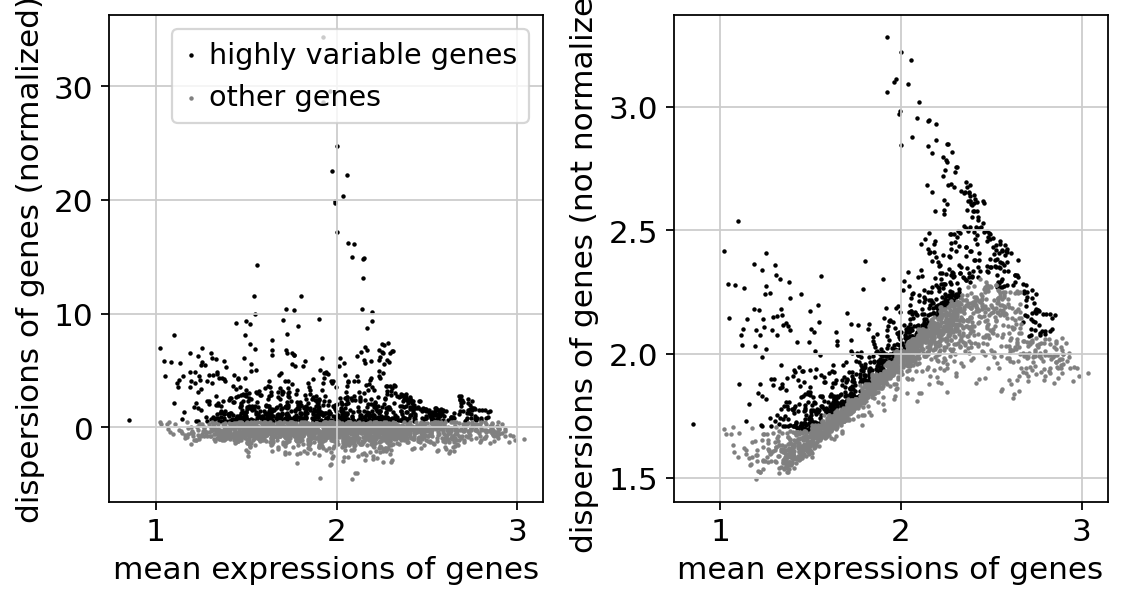

In [22]:
# plot variable genes
sc.pl.highly_variable_genes(adata)

In [23]:
# scale
#run this line if you get the "AttributeError: swapaxes not found"
# adata = adata.copy()

# regress out unwanted variables
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

# scale data, clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

regressing out ['total_counts', 'pct_counts_mt']
    finished (0:00:06)


In [24]:
# pca
sc.pp.pca(adata, svd_solver='arpack', random_state=537)

computing PCA
    with n_comps=50
    finished (0:00:05)


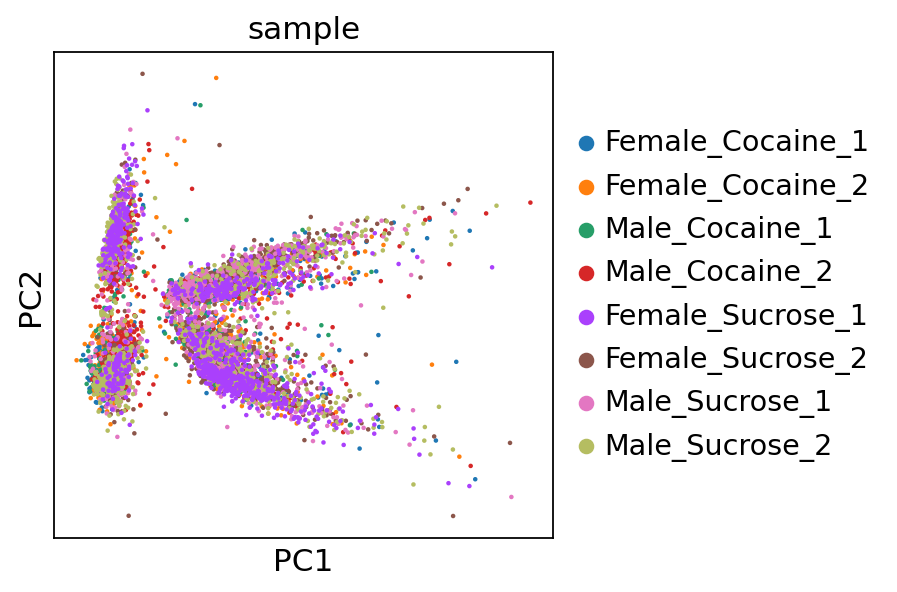

In [25]:
sc.pl.pca(adata, color='sample')

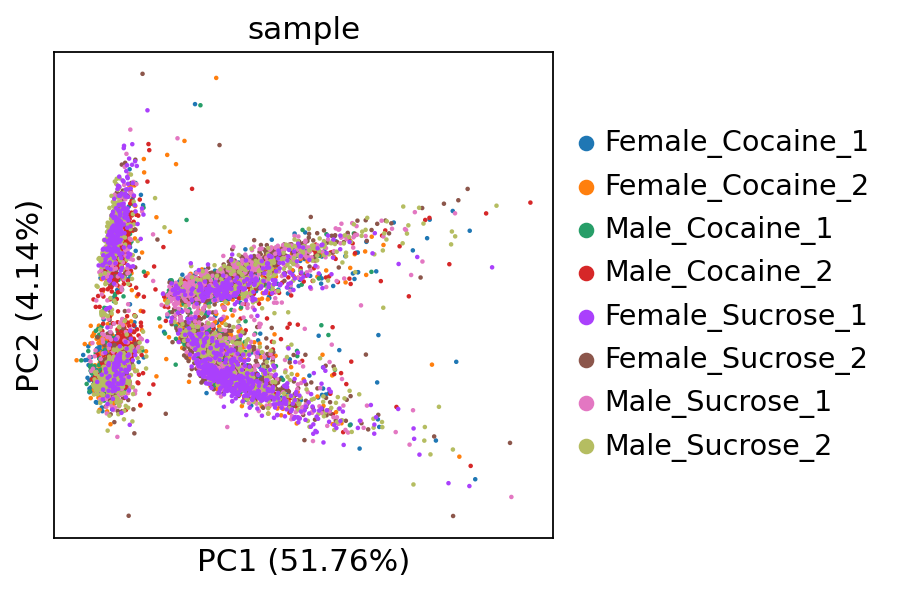

In [26]:
# Plot PCA
sc.pl.pca(
    adata,
    color='sample',
    show=False
)

# Get variance explained
pc1_var = adata.uns['pca']['variance_ratio'][0] * 100
pc2_var = adata.uns['pca']['variance_ratio'][1] * 100

# Change axis labels
ax = plt.gca()
ax.set_xlabel(f"PC1 ({pc1_var:.2f}%)")
ax.set_ylabel(f"PC2 ({pc2_var:.2f}%)")

plt.show()

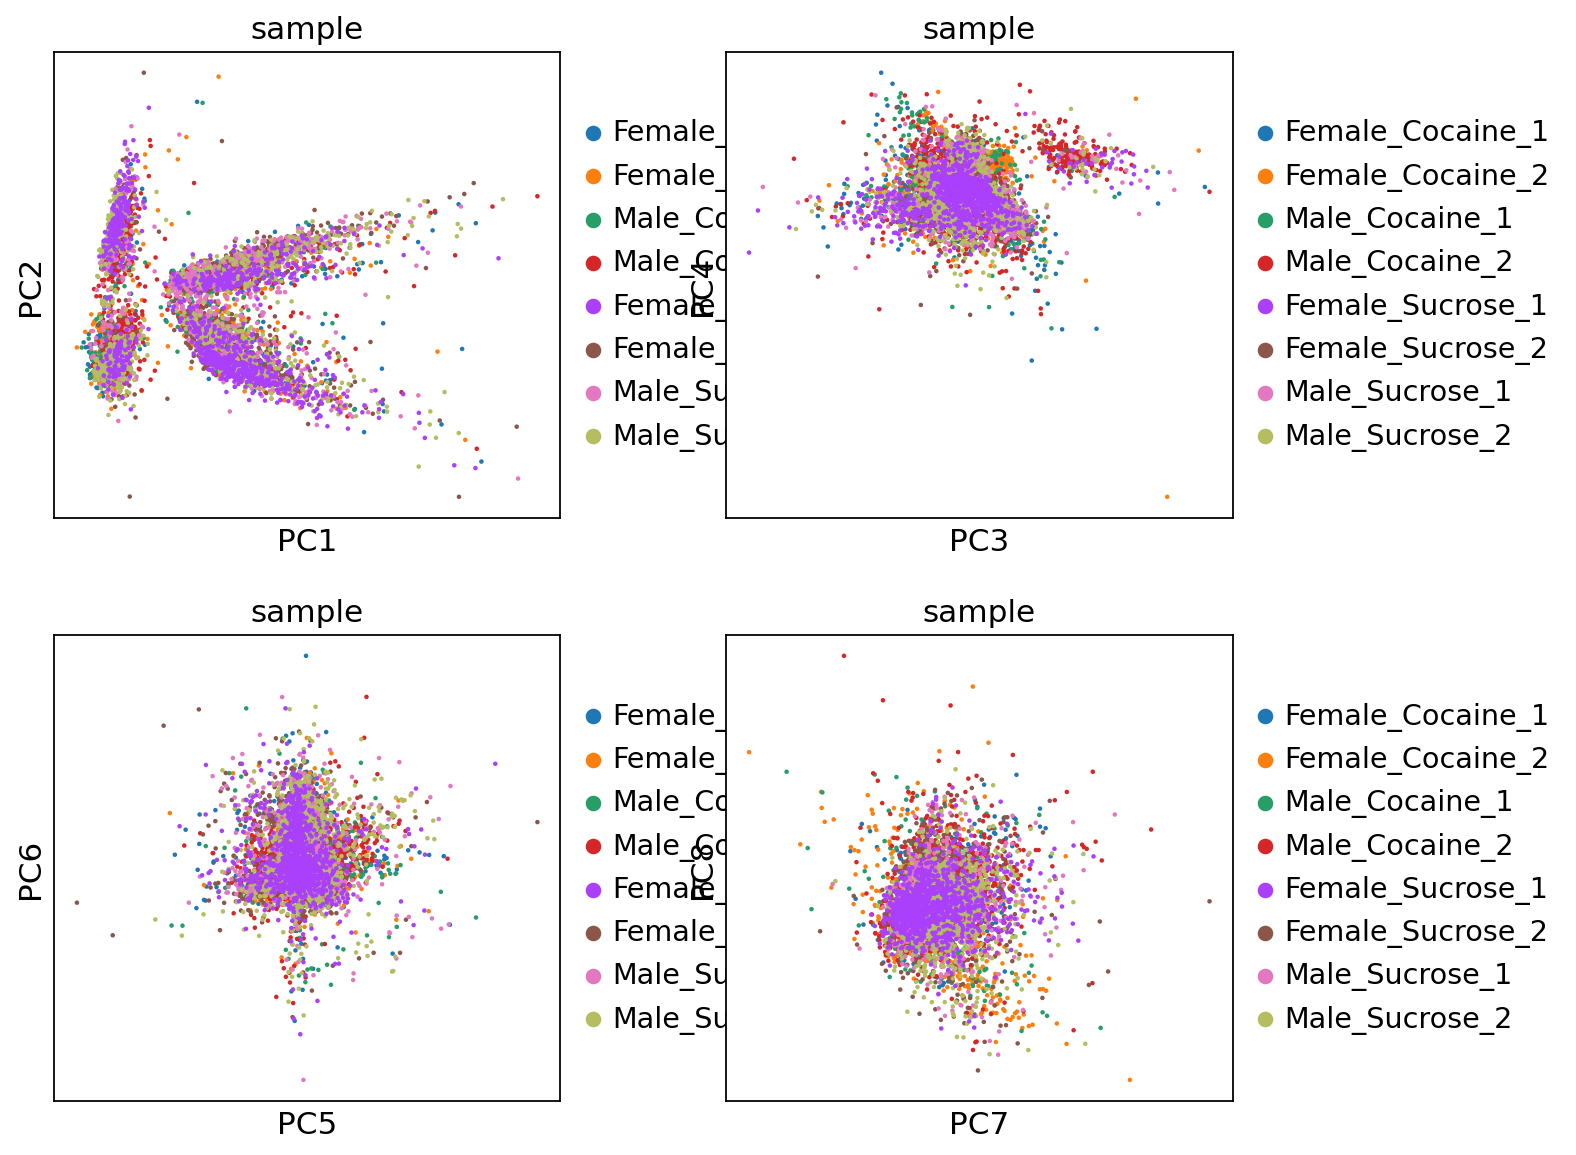

In [27]:
# pca-plot
# plot more PCS
sc.pl.pca(adata, color='sample', components = ['1,2','3,4','5,6','7,8'], ncols=2)

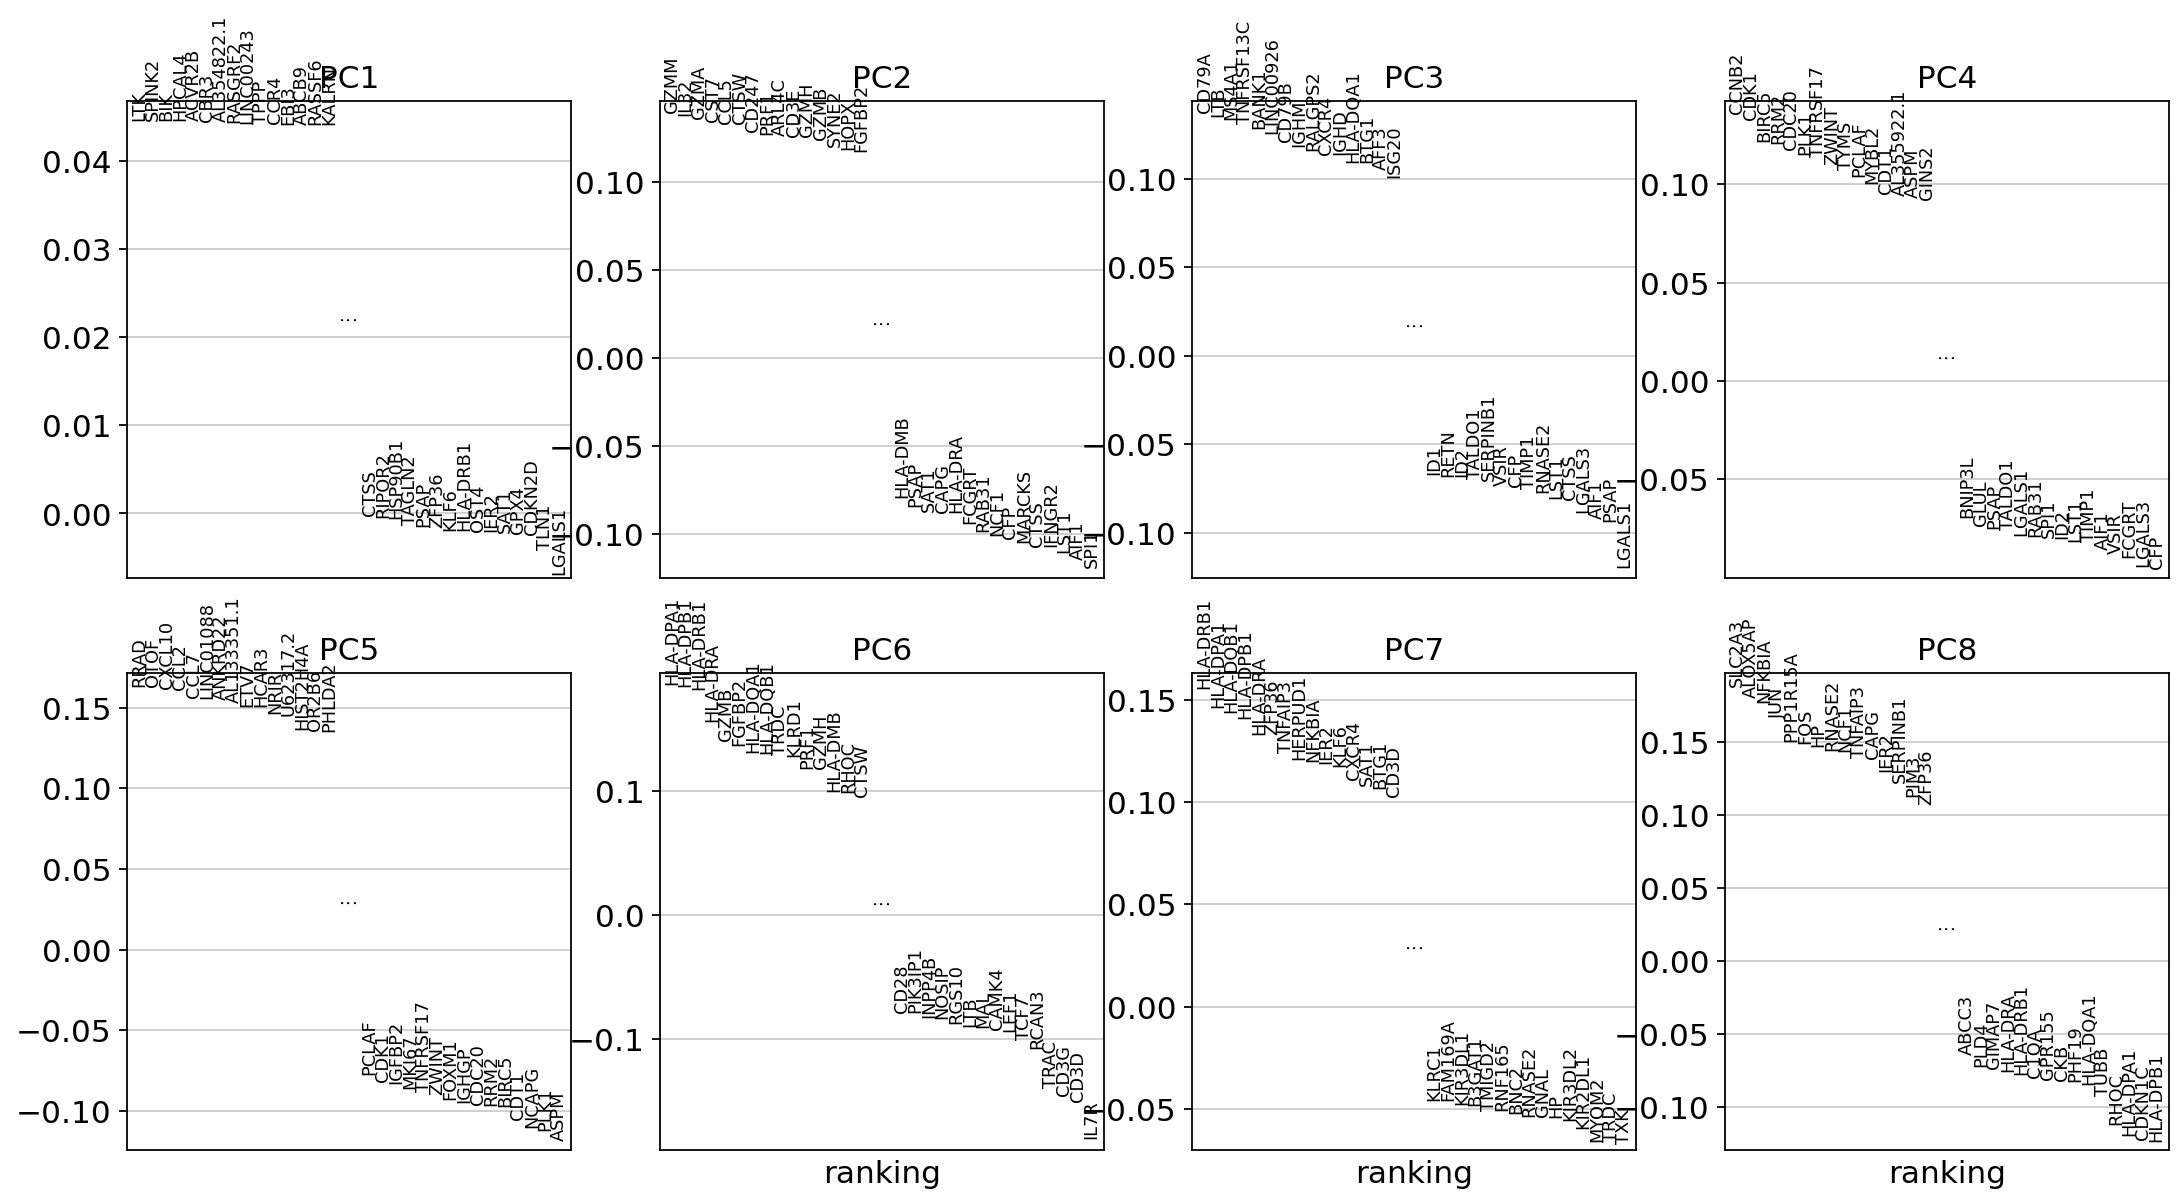

In [28]:
# pca-loadings
#Plot loadings
sc.pl.pca_loadings(adata, components=[1,2,3,4,5,6,7,8])

# OBS! only plots the positive axes genes from each PC!!

In [29]:
for pc in [1, 2, 3, 4]:

    loadings = adata.varm["PCs"][:, pc - 1]

    loading_df = pd.DataFrame({
        "gene": adata.var_names,
        "loading": loadings
    })

    loading_df = loading_df.sort_values("loading")

    print(f"\n===== PC{pc} =====")

    print("\nTop negative-loading genes:")
    print(loading_df.head(10).to_string(index=False))

    print("\nTop positive-loading genes:")
    print(loading_df.tail(10).sort_values("loading", ascending=False).to_string(index=False))


===== PC1 =====

Top negative-loading genes:
    gene   loading
  LGALS1 -0.006924
    TLN1 -0.004126
  CDKN2D -0.002423
    GPX4 -0.002271
    SAT1 -0.002095
    IER2 -0.002091
    OST4 -0.002085
HLA-DRB1 -0.001935
    KLF6 -0.001885
   ZFP36 -0.001553

Top positive-loading genes:
      gene  loading
       LTK 0.044586
    SPINK2 0.044574
       BIK 0.044565
    HPCAL4 0.044562
    ACVR2B 0.044519
      CBR3 0.044401
AL354822.1 0.044399
   RASGRF2 0.044283
 LINC00243 0.044260
      TPPP 0.044209

===== PC2 =====

Top negative-loading genes:
  gene   loading
  SPI1 -0.119061
  AIF1 -0.114949
  LST1 -0.110645
IFNGR2 -0.107091
  CTSS -0.107054
MARCKS -0.105203
   CFP -0.102480
  NCF1 -0.101152
 RAB31 -0.098721
 FCGRT -0.093938

Top positive-loading genes:
 gene  loading
 GZMM 0.139296
 IL32 0.137496
 GZMA 0.136141
 CST7 0.134219
 CCL5 0.133082
 CTSW 0.133079
CD247 0.128922
 PRF1 0.126720
ARL4C 0.126626
 CD3E 0.125787

===== PC3 =====

Top negative-loading genes:
  gene   loading
LGALS1

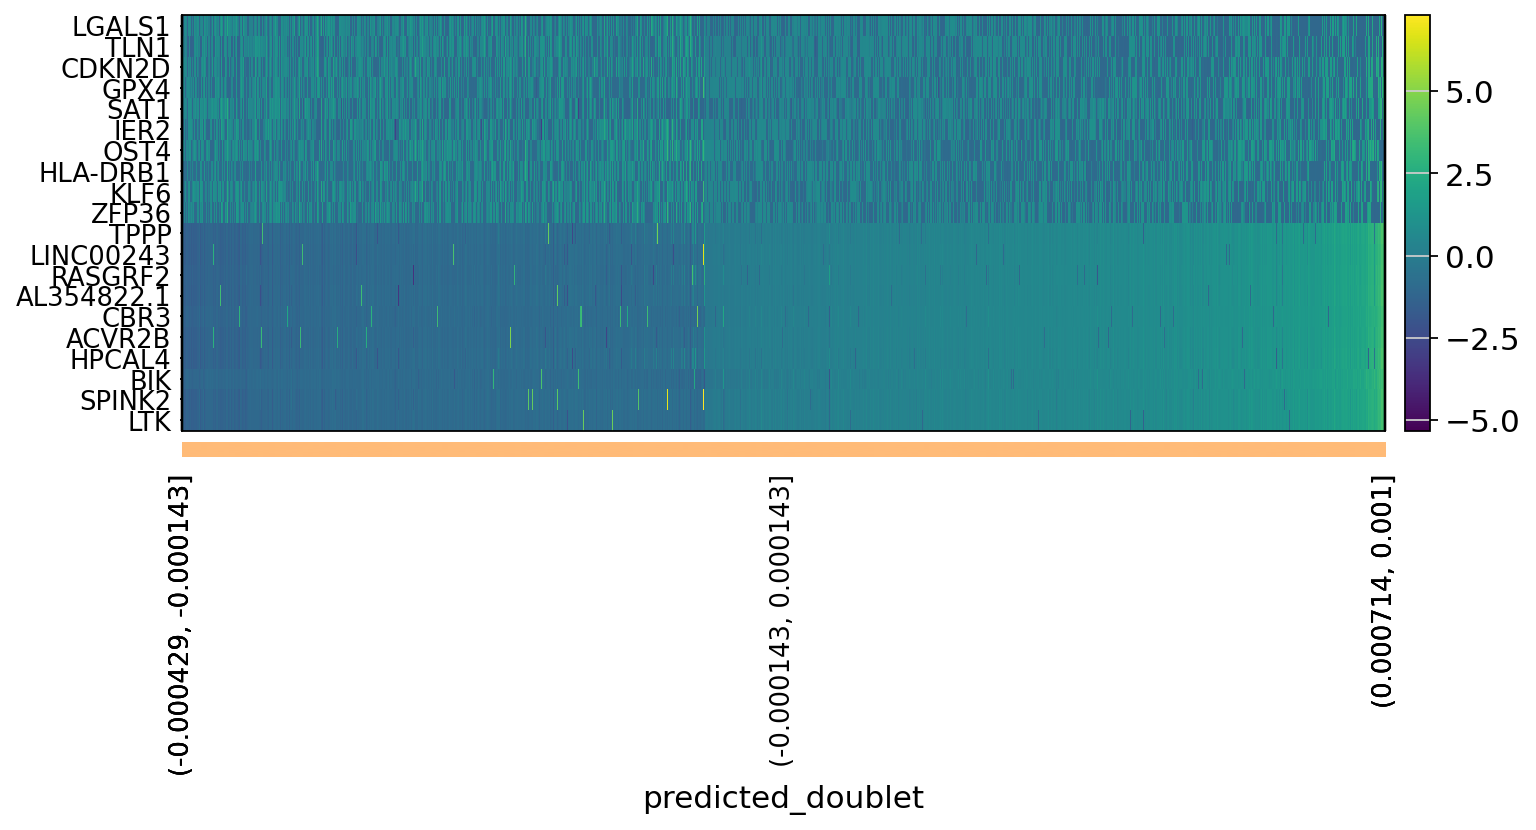

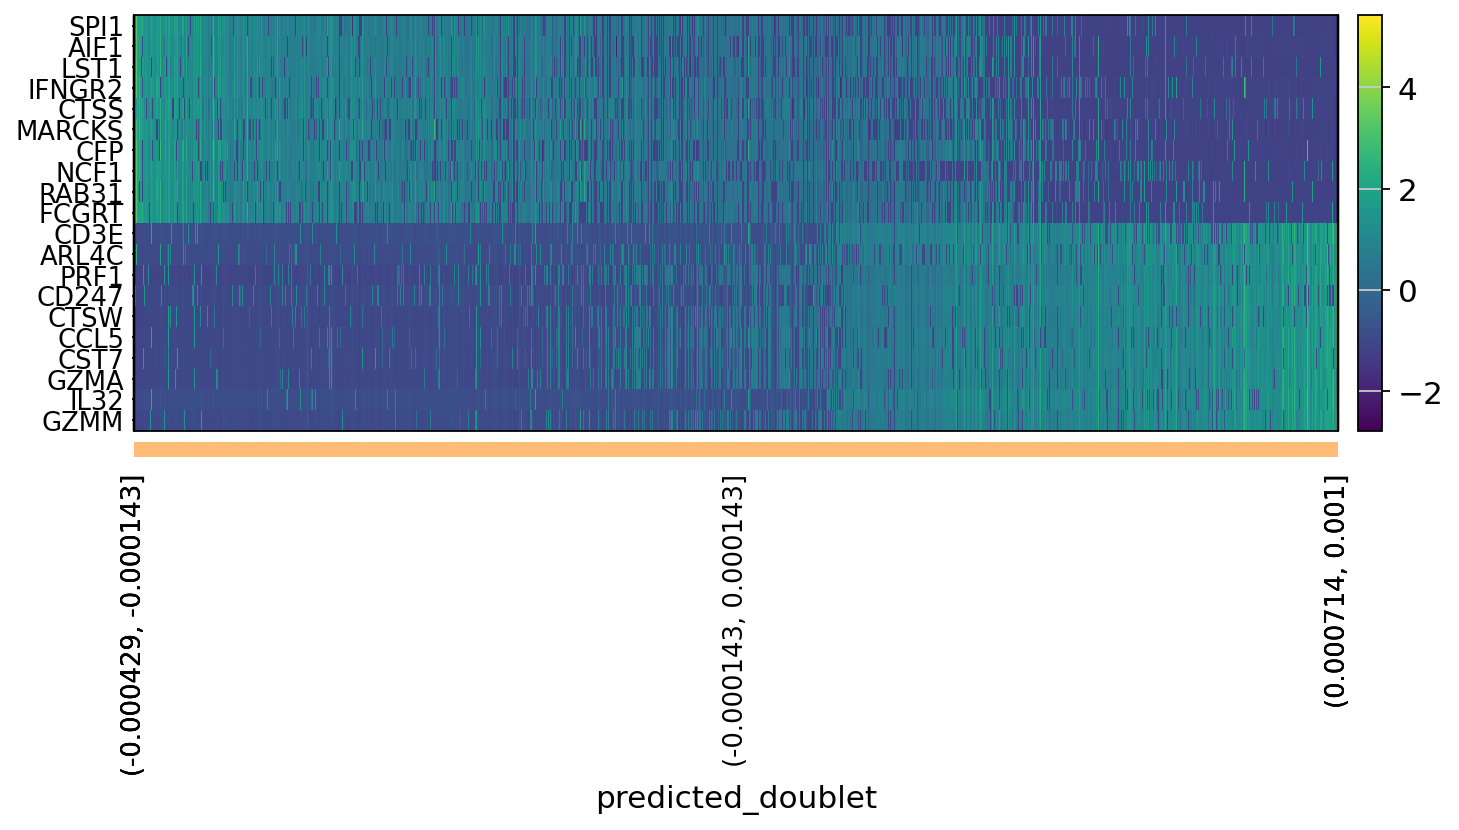

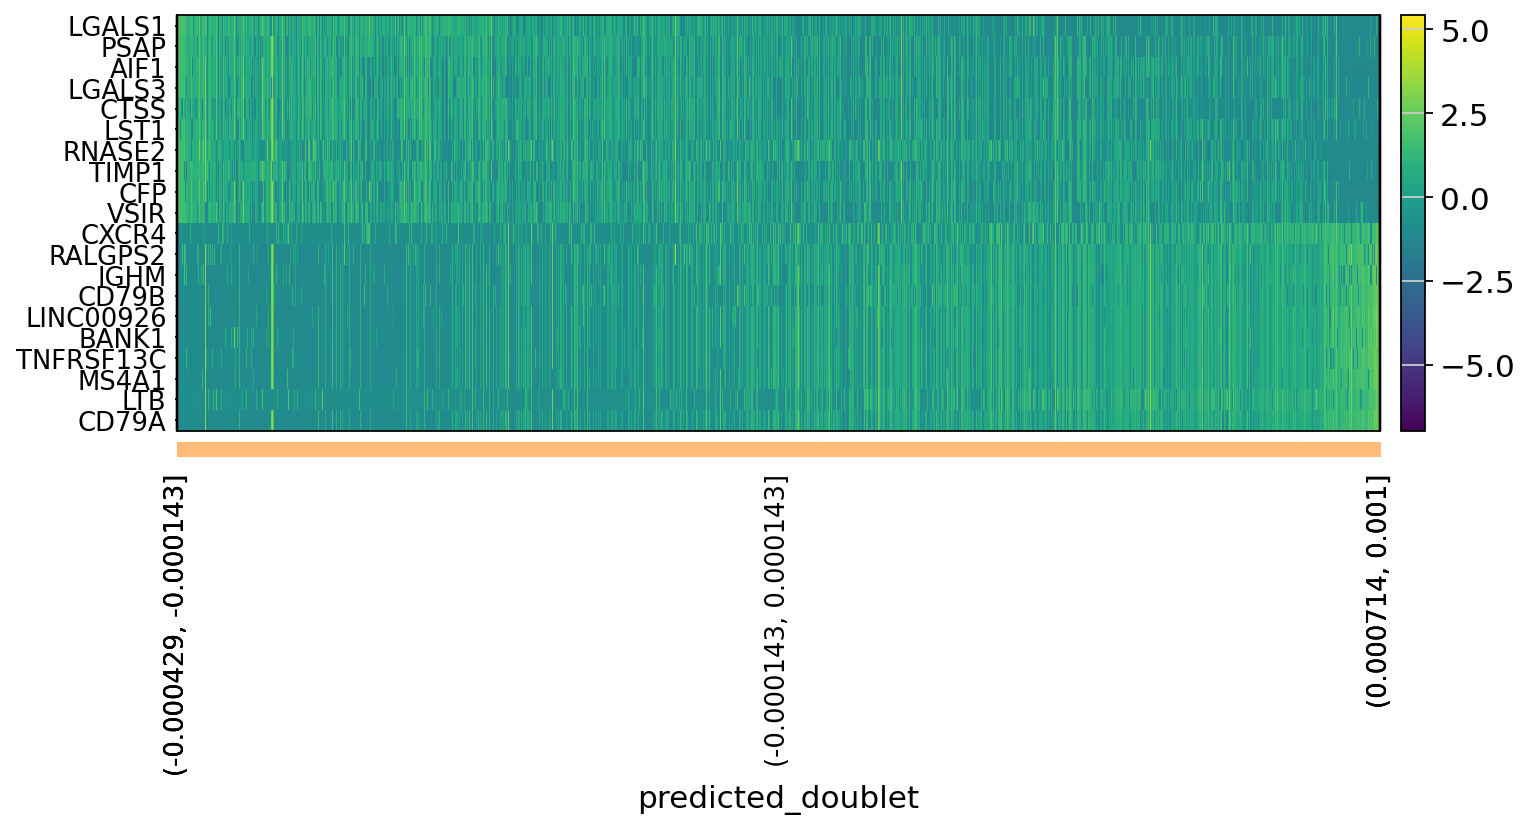

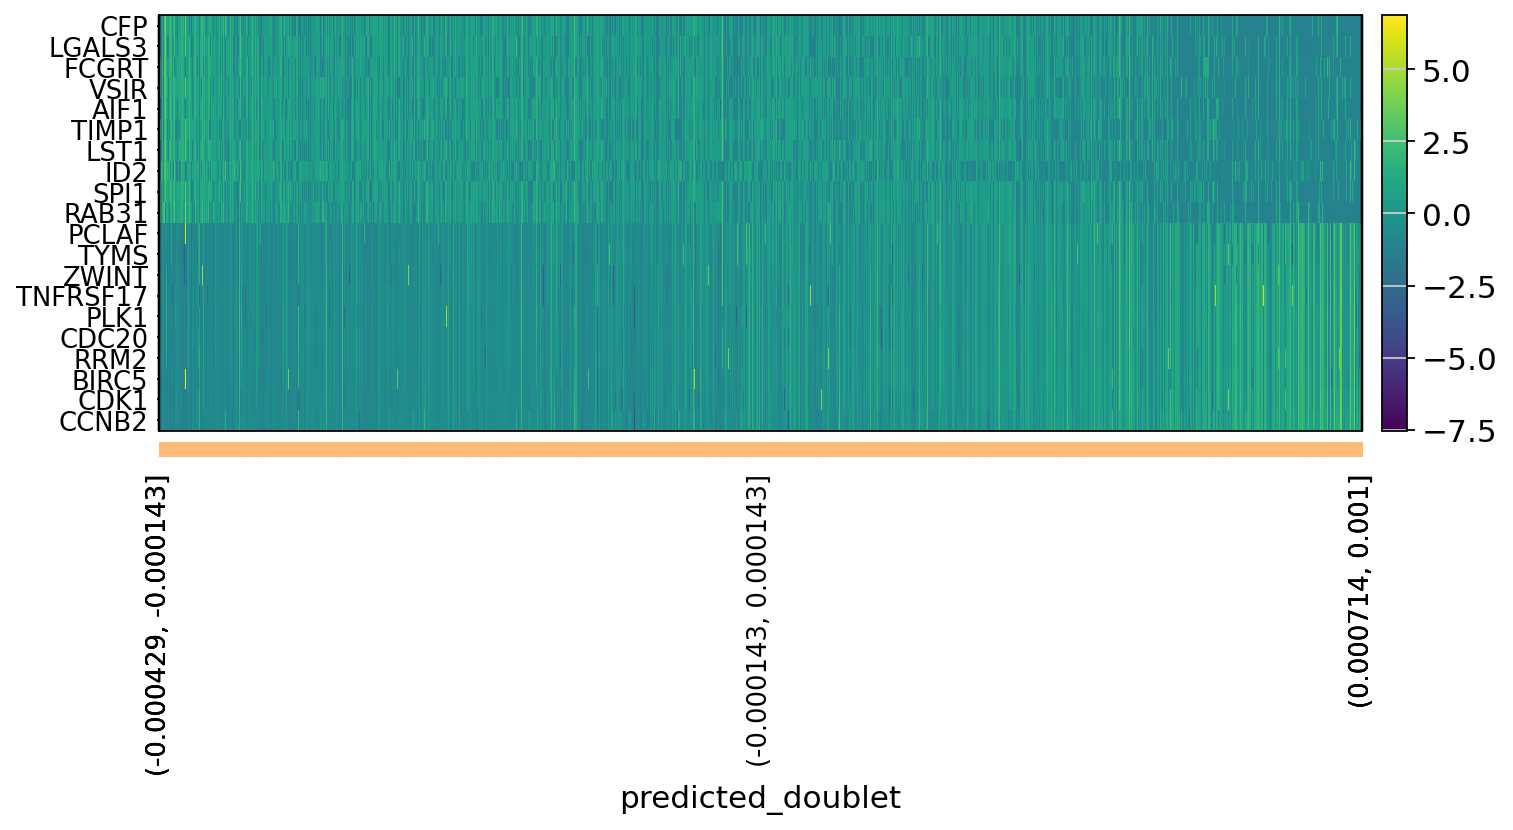

In [31]:
# pca-loadings-heatmap
# adata.obsm["X_pca"] is the embeddings
# adata.uns["pca"] is pc variance
# adata.varm['PCs'] is the loadings

genes = adata.var['gene_ids']

for pc in [1,2,3,4]:
    g = adata.varm['PCs'][:,pc-1]
    o = np.argsort(g)
    sel = np.concatenate((o[:10],o[-10:])).tolist()
    emb = adata.obsm['X_pca'][:,pc-1]
    # order by position on that pc
    tempdata = adata[np.argsort(emb),]
    sc.pl.heatmap(tempdata, var_names = genes[sel].index.tolist(), groupby='predicted_doublet', swap_axes = True, use_raw=False)

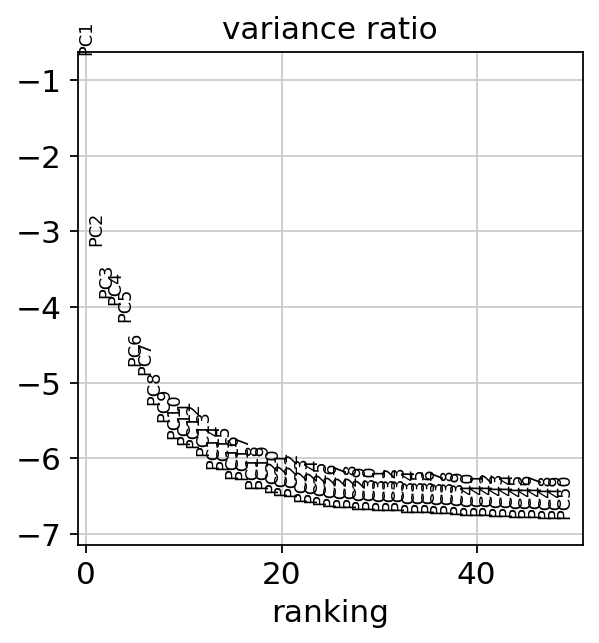

In [32]:
# pca-elbow
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [33]:
# tsne
sc.tl.tsne(adata, n_pcs = 30, random_state=75)

computing tSNE
    using 'X_pca' with n_pcs = 30
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:41)


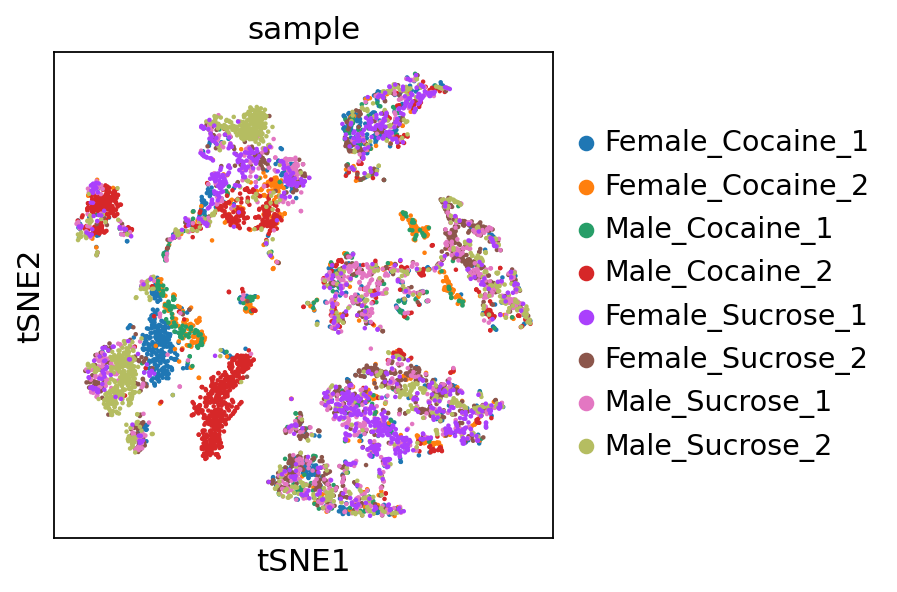

In [34]:
# tsne-plot
sc.pl.tsne(adata, color='sample')

In [35]:
sc.pp.neighbors(adata, n_pcs = 30, n_neighbors = 20, random_state=159)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:54)


computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:16)


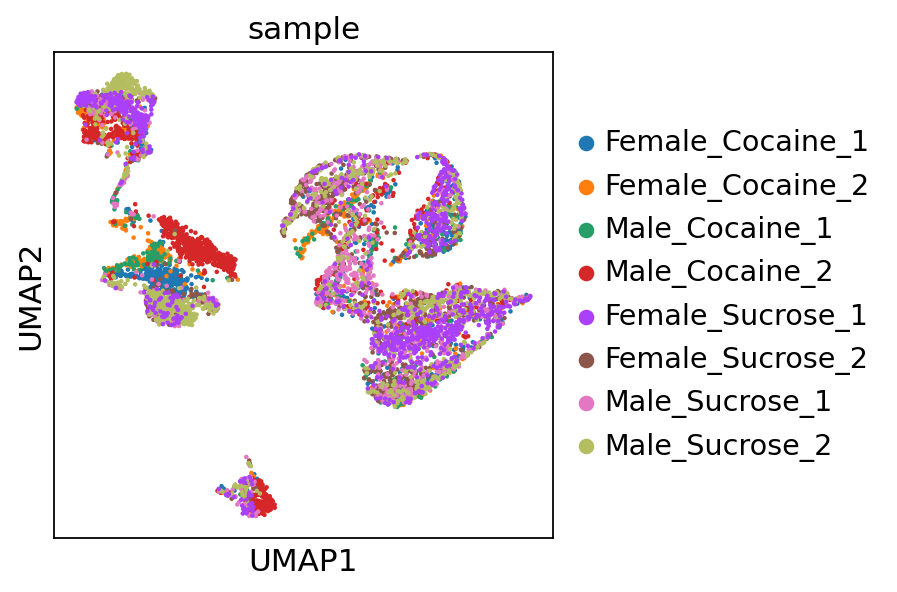

In [36]:
# umap
sc.tl.umap(adata, random_state=331)
sc.pl.umap(adata, color='sample')

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:32)


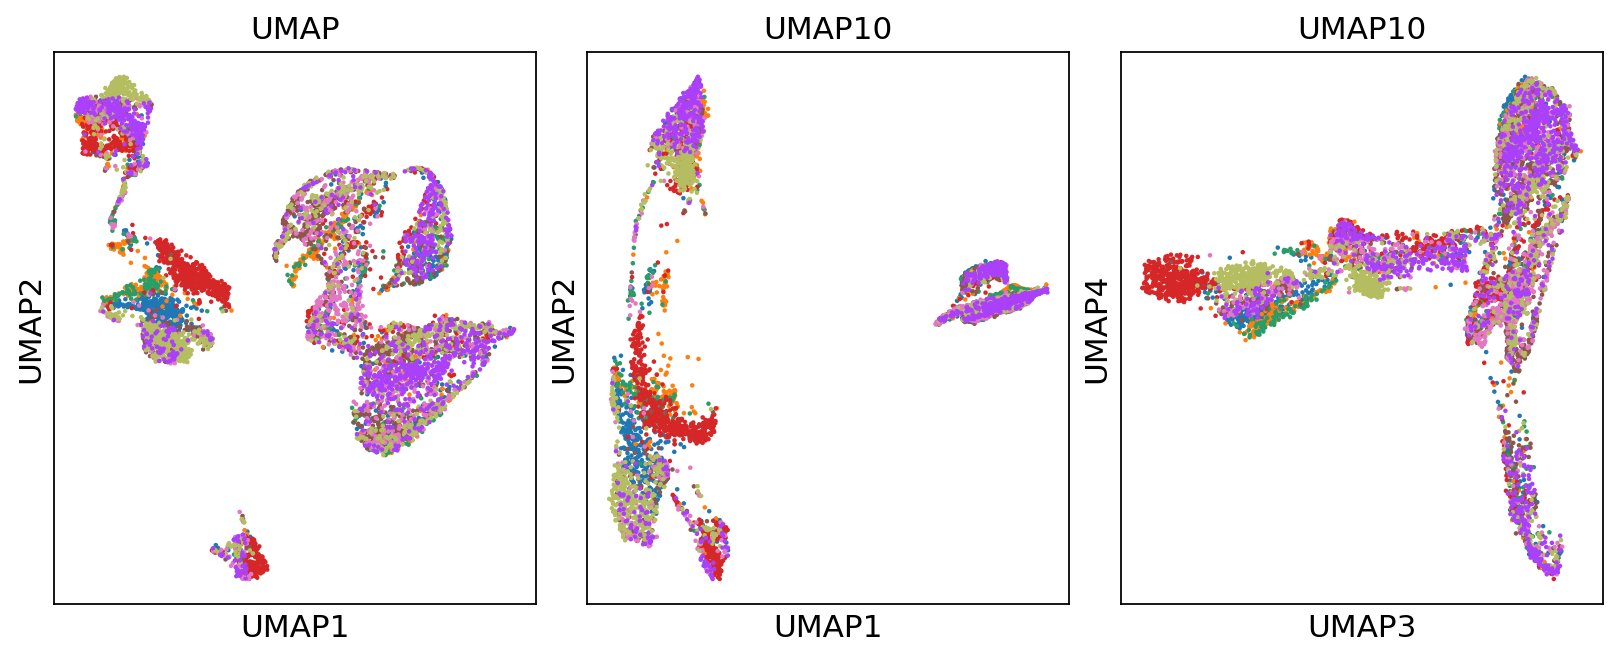

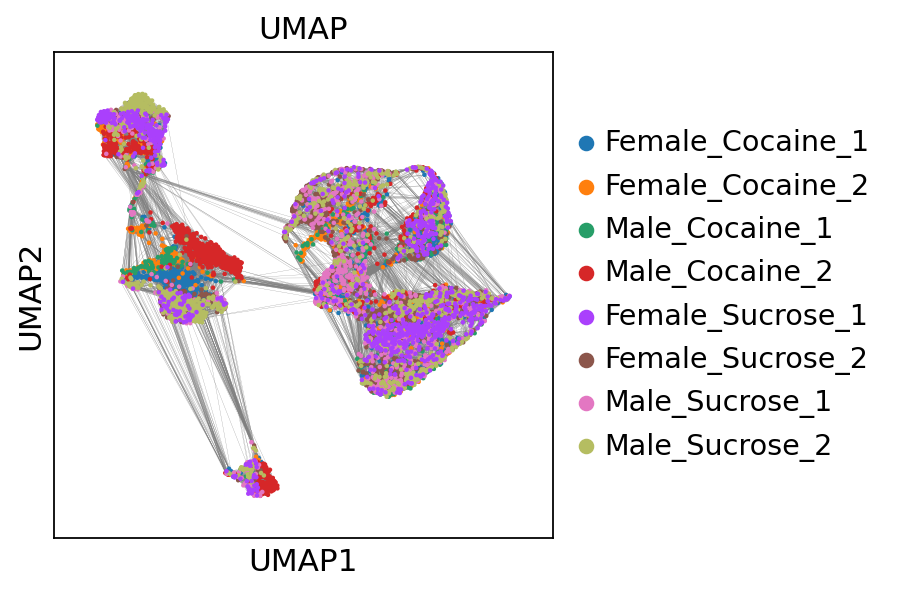

In [37]:
# umap10
# run with 10 components, save to a new object so that the umap with 2D is not overwritten.
umap10 = sc.tl.umap(adata, n_components=10, copy=True, random_state=331)
fig, axs = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)

sc.pl.umap(adata, color='sample',  title="UMAP",
           show=False, ax=axs[0], legend_loc=None)
sc.pl.umap(umap10, color='sample', title="UMAP10", show=False,
           ax=axs[1], components=['1,2'], legend_loc=None)
sc.pl.umap(umap10, color='sample', title="UMAP10",
           show=False, ax=axs[2], components=['3,4'], legend_loc=None)

# we can also plot the umap with neighbor edges
sc.pl.umap(adata, color='sample', title="UMAP", edges=True)

<Axes: title={'center': 'sample'}, xlabel='UMAP1', ylabel='UMAP2'>

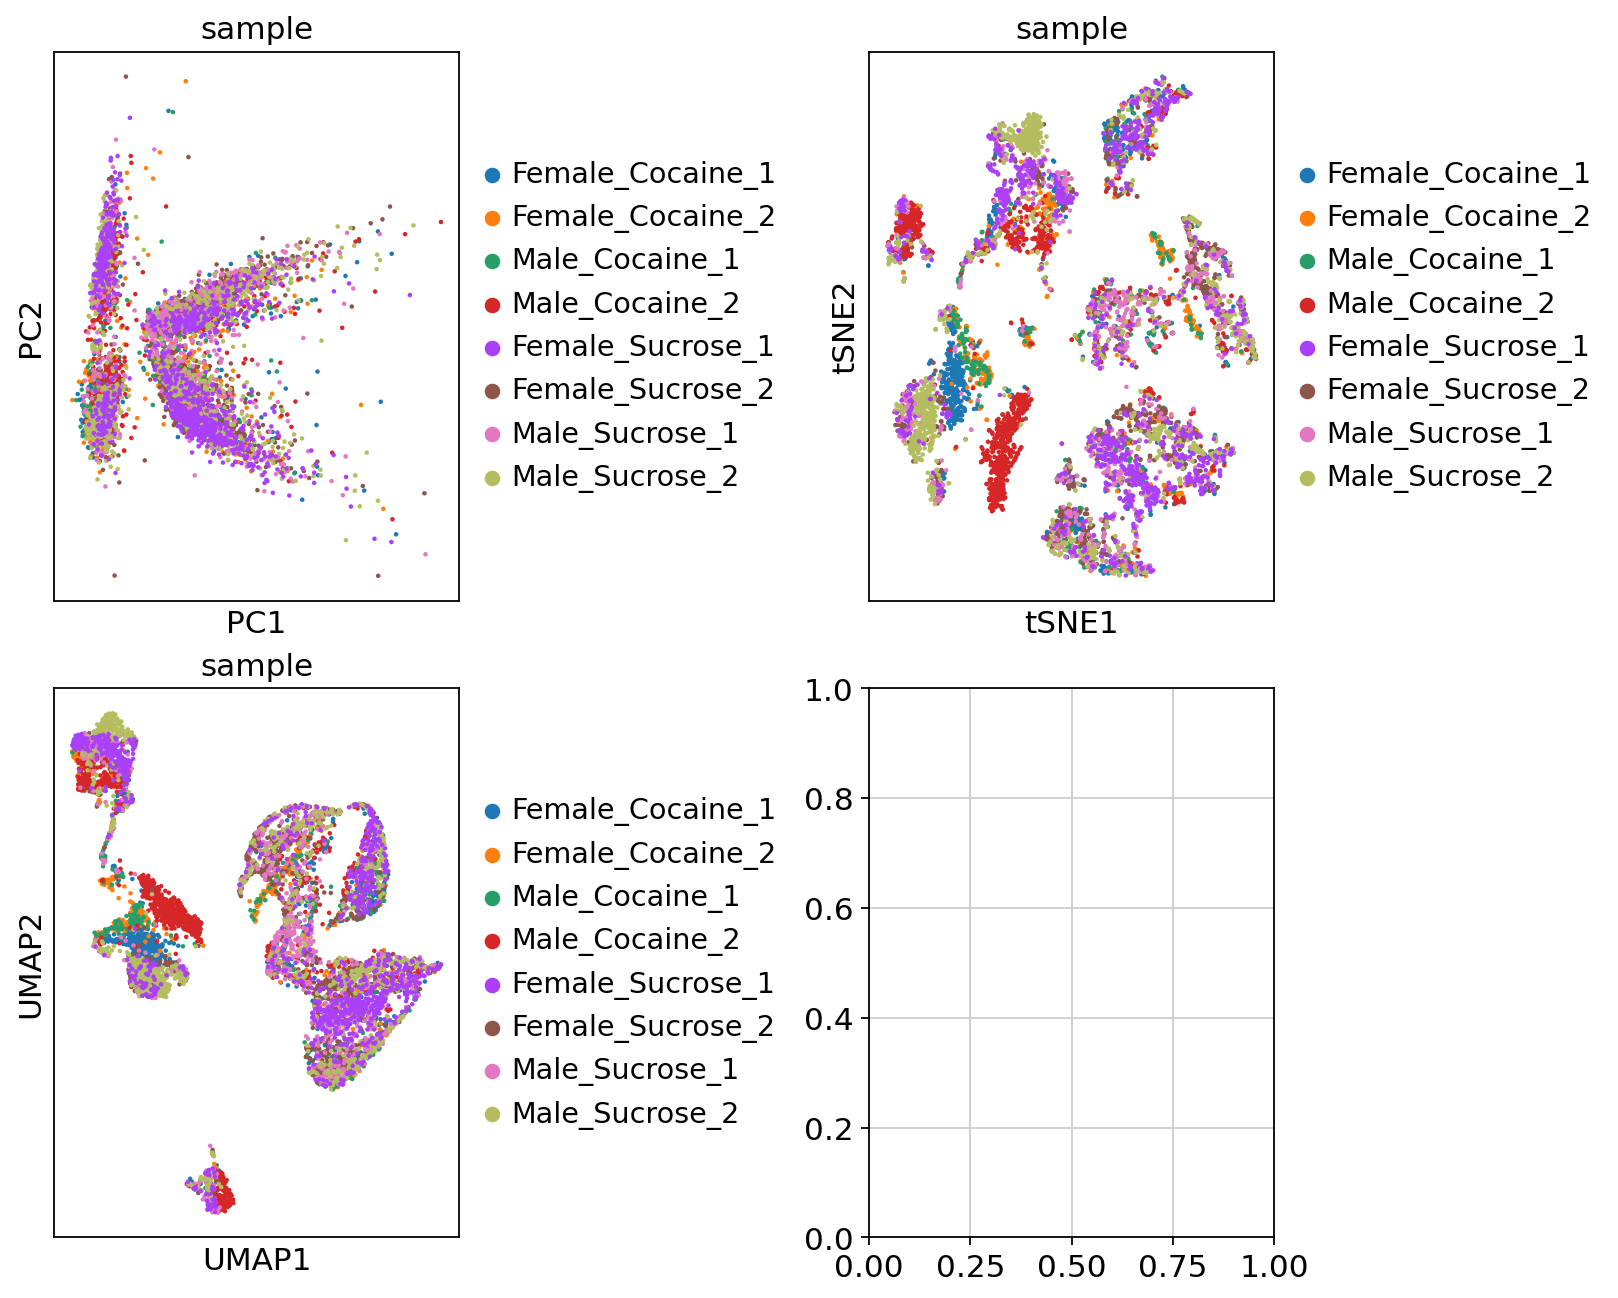

In [38]:
# plot-all
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
sc.pl.pca(adata, color='sample', components=['1,2'], ax=axs[0, 0], show=False)
sc.pl.tsne(adata, color='sample', components=['1,2'], ax=axs[0, 1], show=False)
sc.pl.umap(adata, color='sample', components=['1,2'], ax=axs[1, 0], show=False)

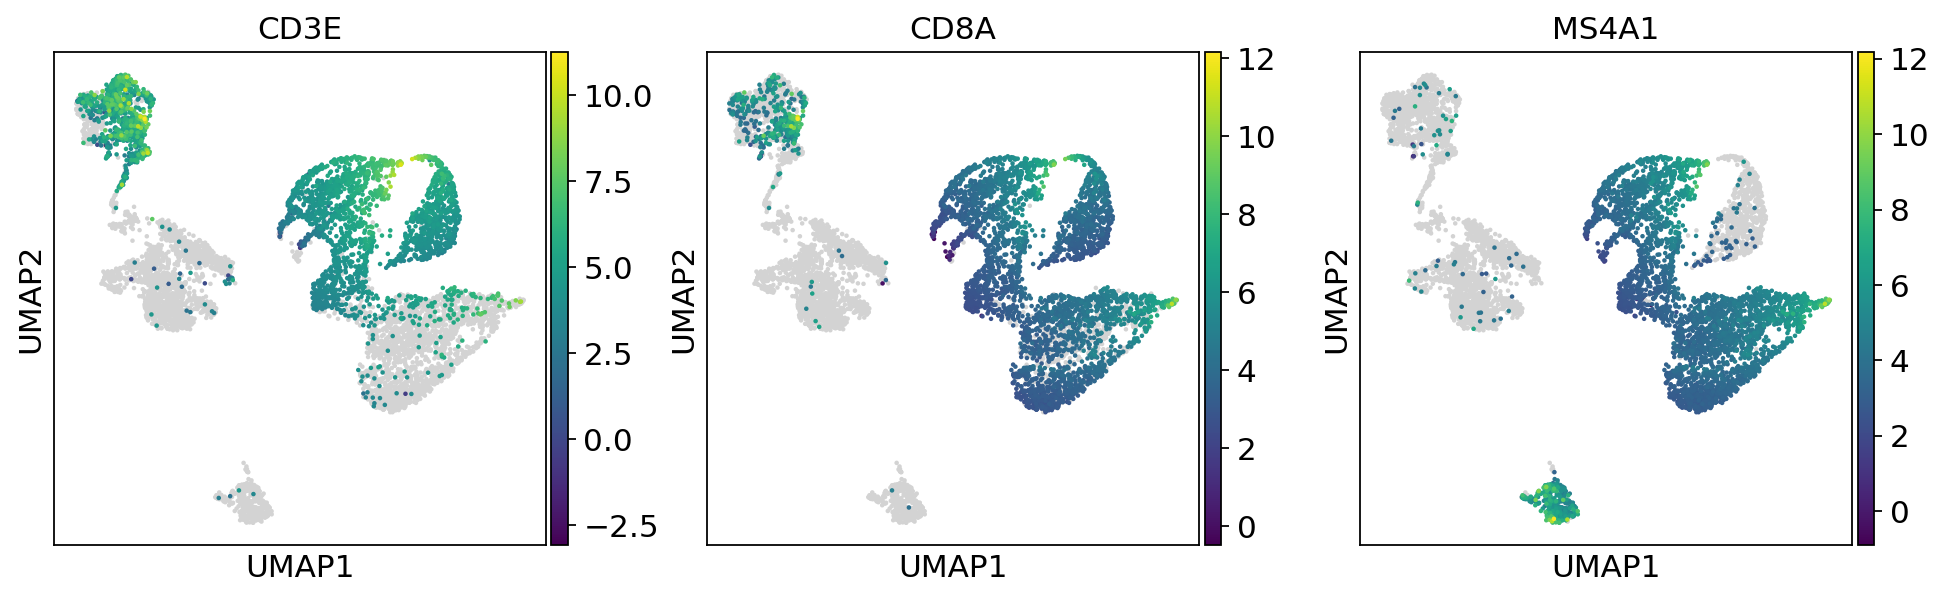

In [39]:
# plot-markers
# present in the current adata object. Defining `varg` here to ensure it's available.
genes  = ["CD3E", "CD4", "CD8A", "GNLY","NKG7", "MS4A1","CD14","LYZ","CST3","MS4A7","FCGR3A"]

var_genes = adata.var.highly_variable

# var_genes.index[var_genes] # This line is not necessary for defining varg
varg = [x for x in genes if x in var_genes.index[var_genes]]
sc.pl.umap(adata, color=varg)

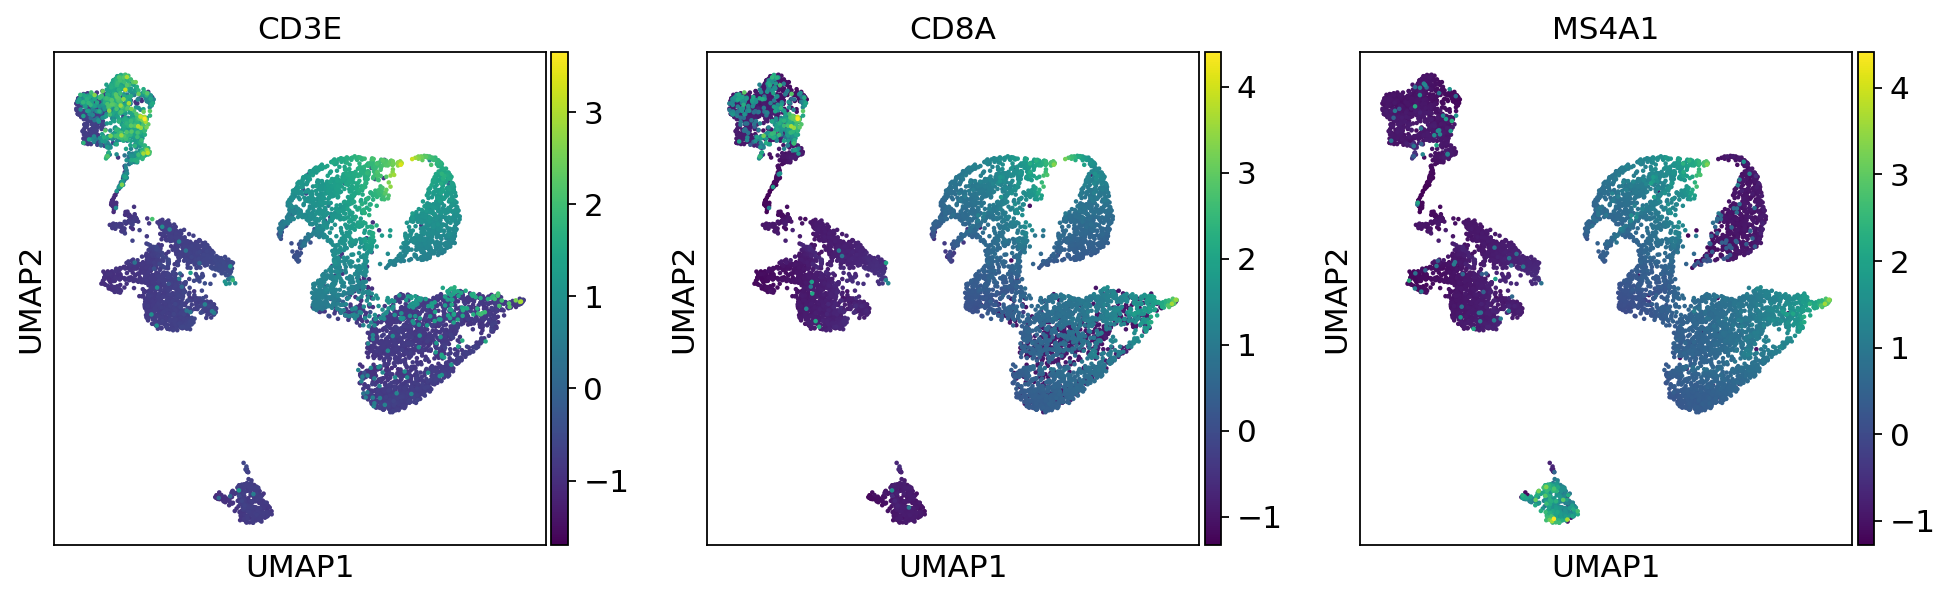

In [40]:
# plot-markers2
genes  = ["CD3E", "CD4", "CD8A", "GNLY","NKG7", "MS4A1","CD14","LYZ","CST3","MS4A7","FCGR3A"]
var_genes = adata.var.highly_variable
var_genes.index[var_genes]
varg = [x for x in genes if x in var_genes.index[var_genes]]
sc.pl.umap(adata, color=varg, use_raw=False)

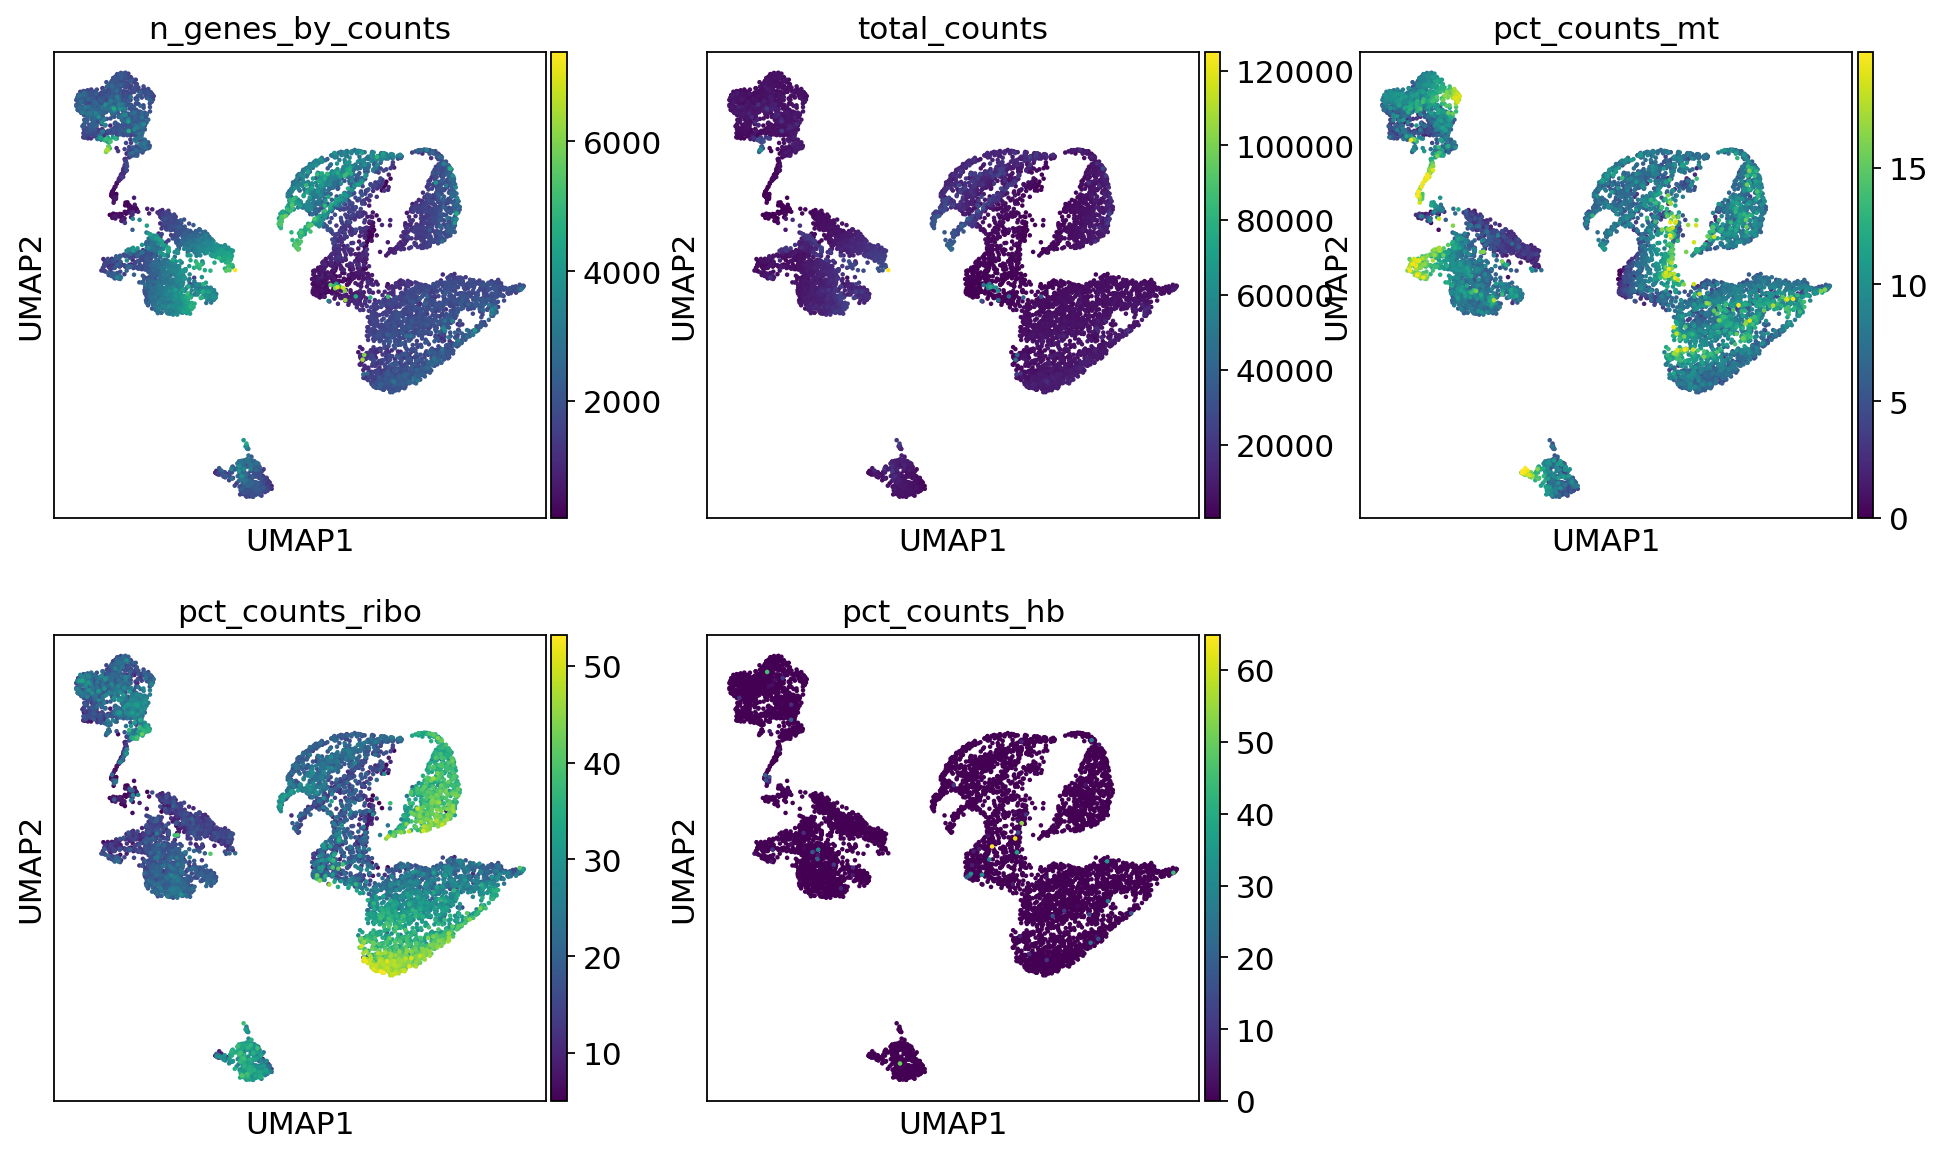

In [41]:
# plot-qc
sc.pl.umap(adata, color=['n_genes_by_counts', 'total_counts', 'pct_counts_mt','pct_counts_ribo', 'pct_counts_hb'], ncols=3,use_raw=False)

In [42]:
# save
adata.write_h5ad('data/filtered/drosophila_qc_preprocessed.h5ad')

FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = 'data/filtered/drosophila_qc_preprocessed.h5ad', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

In [44]:
adata.write_h5ad('/content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad')